- SentencePiece를 이용하여 모델을 만들기까지의 과정이 정상적으로 진행되었는가?  
&rarr; 코퍼스 분석, 전처리, SentencePiece 적용, 토크나이저 구현 및 동작이 빠짐없이 진행되었는가?  
- SentencePiece를 통해 만든 Tokenizer가 자연어처리 모델과 결합하여 동작하는가?  
&rarr; SentencePiece 토크나이저가 적용된 Text Classifier 모델이 정상적으로 수렴하여 80% 이상의 test accuracy가 확인되었다.  
- SentencePiece의 성능을 다각도로 비교분석하였는가?  
&rarr; SentencePiece 토크나이저를 활용했을 때의 성능을 다른 토크나이저 혹은 SentencePiece의 다른 옵션의 경우와 비교하여 분석을 체계적으로 진행하였다.

# 0. 라이브러리 import 및 세팅

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from gensim.models import KeyedVectors
# from gensim.models import keyedvectors

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sentencepiece as spm
from collections import Counter
import os
import glob
import pickle

- 하이퍼 파라미터 (대부분 감정 분석을 위한 하이퍼 파라미터, **VOCAB_SIZE** 공유)
- **토크나이저만 바꾼 성능 비교를 위해 하이퍼 파라미터 유지**

In [2]:
VOCAB_SIZE = 20000 # 어휘 사전 크기
WORD_VECTOR_DIM = 128 # 자체 학습 시 word embeddig vector 차원

In [3]:
SAVE_PATH = "./best_models_spm"

BATCH_SIZE = 512
LR = 0.005
EPOCHS = 20

criterion = nn.BCELoss()

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [5]:
def get_save_model_path(model_name, save_path=SAVE_PATH):
    save_model_path = f"{save_path}/{model_name}.pt"
    return save_model_path

| 구분 | 기존 방식 (Manual Vocab) | SentencePiece 방식 (Subword) |
| :--- | :--- | :--- |
| **사전의 주인** | **사용자** (데이터를 보고 직접 구축) | **SPM 모델** (이미 학습되어 내장됨) |
| **Vocab Size 결정** | 데이터의 모든 단어를 추출한 뒤 결정 | 학습 시 `--vocab_size` 인자로 **미리 설정** |
| **데이터 처리** | NSMC 단어를 빈도순 정렬 후 인덱스 부여 | **학습된 `.model`**이 문장을 보고 ID 할당 |
| **미등록 단어 (OOV)** | 사전에 없는 단어는 처리 불가 (`<UNK>`) | 서브워드 단위로 쪼개어 최대한 처리 가능 |ㅡ

# 1. SentencePiece를 학습할 데이터 준비

## 1.1. 데이터 불러오기

In [6]:
FILE_PATH = "./tok_data/"
FILE_NAME  = "korean-english-park.train.ko"

with open(FILE_PATH + FILE_NAME, "r") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))
print("Example:")
for sen in raw[0:100][::20]: print(">>", sen)

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


## 1.2. 문장 통계량 분석

In [7]:
# corpus를 구성하는 각 문장의 길이를 재고, 
def check_sentence_stats(corpus):
    # min_len = 999
    # max_len = 0
    # sum_len = 0

    # for sen in raw:
    #     length = len(sen)
    #     if min_len > length: min_len = length
    #     if max_len < length: max_len = length
    #     sum_len += length

    # print("문장의 최단 길이:", min_len)
    # print("문장의 최장 길이:", max_len)
    # print("문장의 평균 길이:", sum_len // len(raw))

    # Ex05에서 나온 방법이 더 간결한 듯 
    len_sentence = [len(sentence) for sentence in corpus]
    len_sentence = np.array(len_sentence)

    print('문장 길이 평균: ', np.mean(len_sentence))
    print('문장 길이 최대: ', np.max(len_sentence))
    print('문장 길이 최소: ', np.min(len_sentence))
    print('문장 길이 표준편차: ', np.std(len_sentence))
    print('문장 길이 중위수: ', np.median(len_sentence))

    max_len_sentence = np.max(len_sentence)

    sentence_length = np.zeros((max_len_sentence), dtype=int)

    for sen in corpus:
        sentence_length[len(sen)-1] += 1

    plt.bar(range(max_len_sentence), sentence_length, width=1.0)
    plt.title("Sentence Length Distribution")
    plt.show()

    return sentence_length

In [8]:
def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

# 문장 길이 최소: 1인 경우 확인
check_sentence_with_length(raw, 1)

’


문장 길이 평균:  60.78048935966767
문장 길이 최대:  377
문장 길이 최소:  1
문장 길이 표준편차:  29.748585047389234
문장 길이 중위수:  59.0


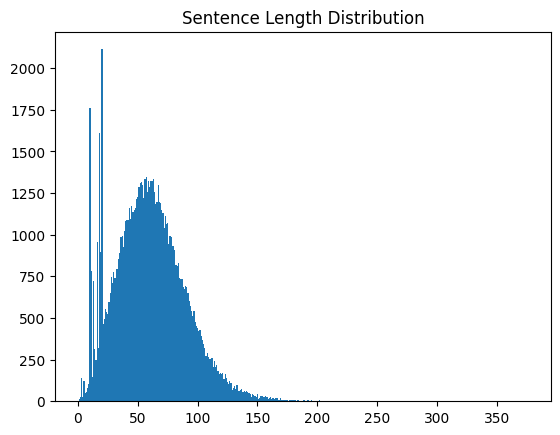

In [9]:
sentence_length = check_sentence_stats(raw)

In [10]:
# 1500개 이상을 차지하는 문장의 길이를 출력

for idx, _sum in enumerate(sentence_length):
    if _sum > 1500:
        print("Outlier Index:", idx+1)

Outlier Index: 11
Outlier Index: 19
Outlier Index: 21


In [11]:
check_sentence_with_length(raw, 11) # 중복 데이터가 그대로 있음

라고 조던이 말했다.
- 모르고 있습니다.
- 네, 보이는군요.
디즈니사만이 아니다.
큰 파티는 아니지요.
의자는 비어 있었다.
이 일은 계속됩니다.
나는 크게 실망했다.
그 이유는 간단하다.
이력서와 자기 소개서
시대가 변하고 있다.
는 돌발질문을 했다.
9. 몇 분간의 명상
하와이, 빅 아일랜드
키스를 잘 하는 방법
키스를 잘 하는 방법
스피어스가 뚱뚱한가?
산 위를 나는 느낌.
세 시간쯤 걸었을까?
(아직 읽고있습니까?
처음에는 장난이었다.
우리는 운이 좋았다.
아기가 숨을 멈출 때
건물 전체 무너져내려
그녀의 아름다운 눈.
대답은 다음과 같다.
"사과할 것이 없다.
폭탄테러가 공포 유발
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1

In [12]:
len(raw), len(set(raw))

(94123, 77591)

Data Size: 77591
문장 길이 평균:  64.53810364604142
문장 길이 최대:  377
문장 길이 최소:  1
문장 길이 표준편차:  27.18329712895357
문장 길이 중위수:  62.0


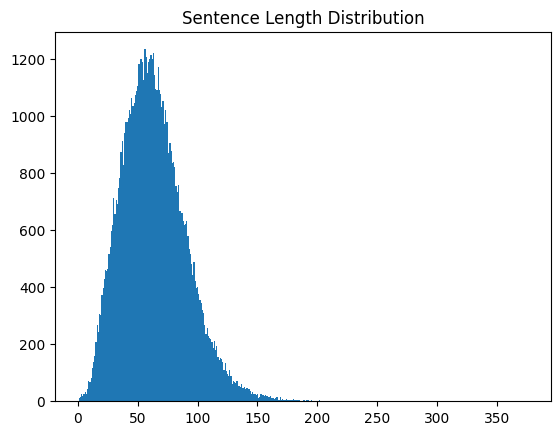

In [13]:
# 중목 문장 제거 후 분포 재확인
cleaned_corpus = list(set(raw))  # set를 사용해서 중복을 제거
print("Data Size:", len(cleaned_corpus))

cleaned_sentence_length = check_sentence_stats(cleaned_corpus)

## 1.3. 최종 문장 선정 및 저장

In [14]:
# 문장 길이가 10이상 ~ 150미만인 데이터만 사용
MAX_LEN = 150
MIN_LEN = 10

문장 길이 평균:  64.02959380038487
문장 길이 최대:  149
문장 길이 최소:  10
문장 길이 표준편차:  25.78900131075263
문장 길이 중위수:  62.0


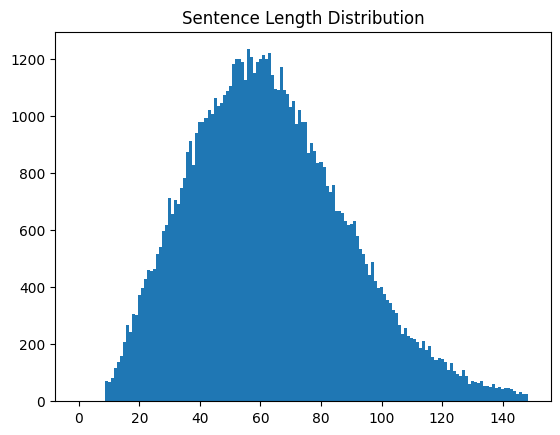

In [15]:
# 길이 조건에 맞는 문장만 선택
filtered_corpus = [s for s in cleaned_corpus if (len(s) < MAX_LEN) & (len(s) >= MIN_LEN)]
filtered_sentence_length = check_sentence_stats(filtered_corpus)

In [16]:
# 정리된 corpus를 저장
with open(FILE_PATH + "./korean-english-park.train.ko.temp", 'w', encoding='utf-8') as f:
    for sentence in filtered_corpus:
        f.write(sentence + '\n')

# 2. SentencePiece 학습

## 2.1. 학습 데이터 불러오기 및 학습

In [17]:
FILE_INPUT = FILE_PATH + 'korean-english-park.train.ko.temp'
vocab_size = VOCAB_SIZE

spm.SentencePieceTrainer.Train(
    input=FILE_INPUT,
    model_prefix="korean_spm",
    vocab_size=vocab_size
    # 원본
    # '--input={} --model_prefix=korean_spm --vocab_size={}'.format(FILE_PATH+temp_file, vocab_size)    
)

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./tok_data/korean-english-park.train.ko.temp
  input_format: 
  model_prefix: korean_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_privacy_noise_le

In [18]:
# SentencePiece 토크나이저 작동 예시
s = spm.SentencePieceProcessor() # 불러와서 
s.Load('korean_spm.model')

True

In [19]:
# SentencePiece를 활용한 sentence -> encoding
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

# SentencePiece를 활용한 sentence -> encoded pieces
# -1: 가능한 모든 후보군 고려
# 0.1: alpha, 랜덤성, 커질수록 무작위로 쪼갤 수 있음
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.',-1, 0.1))

# SentencePiece를 활용한 encoding -> sentence 복원
print(s.DecodeIds(tokensIDs))

[978, 9, 789, 10, 3369, 9, 385, 40, 3]
['▁아버지', '가', '방', '에', '들', '어', '가', '신', '다', '.']
아버지가방에들어가신다.


## 2.2. SentencePiece Tokenize 함수 정의

In [20]:
# 학습 결과 만들어진 어휘 사전 예시
with open("./korean_spm.vocab", 'r') as f:
    vocab_dict = f.readlines() 

print(type(vocab_dict))
print(len(vocab_dict))
print(vocab_dict[:5])

<class 'list'>
20000
['<unk>\t0\n', '<s>\t0\n', '</s>\t0\n', '.\t-3.29958\n', '을\t-3.73512\n']


In [21]:
def sp_tokenize(s, corpus):

    tensor = []

    for sen in corpus:
        tensor.append(s.EncodeAsIds(sen)) # text 토큰을 정수 인덱스 형태로 변환

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines() # 학습 결과 만들어진 어휘 사전을 읽어옴

    word_index = {}
    index_word = {}

    # 어휘 사전에 있는 어휘는 \t로 구분되어 있음
    for idx, line in enumerate(vocab): 
        word = line.split("\t")[0] # 어휘(단어)만 가져와서 word에 할당

        word_index.update({word:idx}) # word: idx 딕셔너리에 추가
        index_word.update({idx:word}) # idx: word 딕셔너리에 추가

     # MAX_LEN보다 짧은 문장에 zero-padding 처리
    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

# 3. SentencePiece 토크나이저 적용

In [22]:
def load_data(train_data, test_data, sp_tokenizer):
    '''
    train_data: DataFrame 타입
    train_data: DataFrame 타입
    (num_words: vocab size) -> 사용 안 함

    0. row 별 str 형식의 문장 단위 데이터를 불러옴
    1. 중복 제거
    2. 결측치 제거
    3. (형태소 단위로 토큰화) -> subword 단위 토큰화
    (불용어 제거) -> 사용 안 함
    (등장 횟수 순서대로 인덱싱하여 word_to_idx 생성 (길이: num_words)) -> 사용 안 함
    (word_to_idx를 이용해 x_train, y_test에 있는 단어를 인덱스로 변환) -> 사용 안 함
    4. x_train, y_train, x_test, y_test, word_to_idx 반환
    '''    
    
    # 1. 중복 제거 / 2. 결측치 제거
    train_data.drop_duplicates(subset=['document'], inplace=True) # 1. 중복 제거
    train_data = train_data.dropna(how='any') # 2. 결측치 제거
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how='any')

    x_train = [sp_tokenizer.EncodeAsIds(str(sentence)) for sentence in train_data['document']]
    x_test = [sp_tokenizer.EncodeAsIds(str(sentence)) for sentence in test_data['document']]

    # word_to_idx 생성 (모델 내부의 사전을 가져옴)
    word_to_idx = {sp_tokenizer.IdToPiece(i): i for i in range(sp_tokenizer.get_piece_size())}

    return x_train, np.array(list(train_data['label'])), x_test, np.array(list(test_data['label'])), word_to_idx

In [23]:
# 최대 문장 길이보다 짧은 문장에 패딩 처리하는 함수
def pad_sequences(data, maxlen):
    padded_data = []
    for sentence in data:
        if len(sentence) < maxlen:
            sentence += [0]*(maxlen-len(sentence)) # MAX_LEN보다 짧은 문장은 뒤에 <PAD> 토큰을 채우고,
        else:
            sentence = sentence[:maxlen] # MAX_LEN보다 긴 문장은 MAX_LEN만큼 자름
        padded_data.append(sentence)
    return np.array(padded_data)

## 3.1. 데이터 준비 및 전처리

In [24]:
# 원본 .txt 파일을 dataframe 형식으로 불러오기
train_data = pd.read_table("./sentiment_data/ratings_train.txt")
test_data = pd.read_table("./sentiment_data/ratings_test.txt")
train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [25]:
# SentencePiece 토크나이저 load
sp_tokenizer = spm.SentencePieceProcessor() # 불러와서 
sp_tokenizer.Load('korean_spm.model')

True

In [26]:
x_train, y_train, x_test, y_test, word_to_idx = load_data(train_data, test_data, sp_tokenizer)

## 3.2. 최대 문장 길이 설정

In [27]:
total_data_txt = list(x_train) + list(x_test)

num_tokens = [len(tokens) for tokens in total_data_txt]
num_tokens = np.array(num_tokens)

print('문장 길이 평균: ', np.mean(num_tokens))
print('문장 길이 최대: ', np.max(num_tokens))
print('문장 길이 표준편차: ', np.std(num_tokens))
print('문장 길이 중위수: ', np.median(num_tokens))

문장 길이 평균:  21.69459759699804
문장 길이 최대:  140
문장 길이 표준편차:  17.23278942362822
문장 길이 중위수:  17.0


- Mecab 형태소 분석기로 토큰화 했을 때의 통계량  

문장 길이 평균:  15.9710452085861  
문장 길이 최대:  116  
문장 길이 표준편차:  12.844097739499528  
문장 길이 중위수:  12.0  
pad_sequences maxlen:  41  
전체 문장의 93.43%가 maxlen 설정값 이내에 포함됩니다.  
&rarr; SentencePiece가 subword로 잘게 쪼개니까, Mecab 때보다 문장 길이가 더 길어짐  
&rarr; 최대한 조건을 통일하기 위해 이번 task에서도 최대 문장 길이를 "평균 + 2*표준편차" 사용

In [28]:
# 전체 데이터 중 "문장 길이 평균 + 2*표준편차" 길이를 SENTS_MAX_LEN(최대 문장 길이)로 지정해서 사용
max_tokens = np.mean(num_tokens) + 2*np.std(num_tokens)
SENTS_MAX_LEN = int(max_tokens)
print('pad_sequences maxlen: ', SENTS_MAX_LEN)
print(f"전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens) *100:.2f}%가 SENTS_MAX_LEN 설정값 이내에 포함됩니다.")

pad_sequences maxlen:  56
전체 문장의 93.63%가 SENTS_MAX_LEN 설정값 이내에 포함됩니다.


In [29]:
# pad 토큰 0인 것 확인 
sp_tokenizer.PieceToId('<pad>')

0

In [30]:
x_train_encoded = pad_sequences(x_train, SENTS_MAX_LEN)
x_test_encoded = pad_sequences(x_test, SENTS_MAX_LEN)

In [31]:
# padding 적용 확인
x_train_encoded[0]

array([  299,    84,  4431,     3,     3, 13257,  9001,  1214,    86,
         810,   969,  2519,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0])

## 3.3. Data Loader 생성

### 3.3.1. validation set 구성 

In [32]:
# test set 크기 만큼 training set에서 분리해서 validation set 생성
len_val = len(x_test)
print(len_val)

# x_val = x_train_tensor[:len_val]
x_val = x_train_encoded[:len_val]
y_val = y_train[:len_val]

# partial_x_train = x_train_tensor[len_val:]
partial_x_train = x_train_encoded[len_val:]
partial_y_train = y_train[len_val:]

print(partial_x_train.shape)
print(partial_y_train.shape)

49157
(97025, 56)
(97025,)


### 3.3.2. Data Loader 생성

In [33]:
partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)

x_val_tensor = torch.tensor(x_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

x_test_tensor = torch.tensor(x_test_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float)

In [34]:
trainset = TensorDataset(partial_x_train_tensor, partial_y_train_tensor)
validset = TensorDataset(x_val_tensor, y_val_tensor)
testset = TensorDataset(x_test_tensor, y_test_tensor)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE, shuffle=False)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

# 4. 감정 분석 모델 정의

RNN, LSTM 정의 후 모델 인스턴스 생성 시 파라미터 값을 통해 stacked RNN, BiLSTM 모델 사용

## 4.1. RNN

In [35]:
class SentRNN(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, n_layers=1, embedding_mat=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        if embedding_mat is not None: # 사전 학습 된 임베딩을 사용할 경우
            self.embedding.weight = nn.Parameter(torch.tensor(embedding_mat, dtype=torch.float32))
            self.embedding.weight.requires_grad = True
            print("using pre-trained word vectors...")
        self.dropout = nn.Dropout(0.5)
        # n_layers로 stacked rnn 조절
        self.rnn = nn.RNN(input_size=word_vector_dim, hidden_size=word_vector_dim, num_layers=n_layers, 
                           nonlinearity='tanh', batch_first=True)
        self.fc1 = nn.Linear(word_vector_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)
        out, hh = self.rnn(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = F.relu(self.fc1(out))
        out = torch.sigmoid(self.fc2(out))
        return out


## 4.2. LSTM

In [36]:
class SentLSTM(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, bidirectional=False, embedding_mat=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        if embedding_mat is not None: # 사전 학습 된 임베딩을 사용할 경우
            self.embedding.weight = nn.Parameter(torch.tensor(embedding_mat, dtype=torch.float32))
            self.embedding.weight.requires_grad = True
            print("using pre-trained word vectors...")
        self.dropout = nn.Dropout(0.5)
        # bidirectional로 biLSTM 설정 -> output이 출력단, 입력단 2개가 나오므로 fc1의 input size를 2배
        self.lstm = nn.LSTM(word_vector_dim, word_vector_dim, batch_first=True, bidirectional=bidirectional)
        if bidirectional:
            self.fc1 = nn.Linear(word_vector_dim*2, 64)
        else:    
            self.fc1 = nn.Linear(word_vector_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)
        out, (hh, cn) = self.lstm(x)
        if self.lstm.bidirectional:
            out = torch.mean(out, dim=1) # biLSTM 설정 시 양방향 정보 평균해서 사용
        else:
            out = out[:, -1, :]
        out = self.dropout(out)
        out = F.relu(self.fc1(out))        
        out = torch.sigmoid(self.fc2(out))
        return out


# 5. 감정 분석 모델 학습

## 5.1. 학습 및 테스트 함수 정의

In [37]:
def make_results_dict():
    res_dict = {
        'train_losses': [],
        'val_losses': [],
        'train_accs': [],
        'val_accs': []               
    }    
    return res_dict

In [38]:
def train_model(model, epochs, criterion, lr, trainloader, validloader, save_model_path):
    
    res_dict = make_results_dict()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss = 99999

    for epoch in range(epochs):
        model.train()
        r_loss = 0.
        correct = 0
        total = 0

        for inputs, labels in trainloader:        
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()

            r_loss += loss.item() # 배치에 대한 평균 loss

            predicted = (outputs.squeeze() > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += len(labels)
        
        res_dict['train_losses'].append(r_loss / len(trainloader))
        res_dict['train_accs'].append(correct / total)

        model.eval()
        val_loss = 0.
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in validloader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), labels)
                val_loss += loss.item()
                
                predicted = (outputs.squeeze() > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += len(labels)

            if val_loss/len(validloader) < best_loss:
                best_loss = val_loss/len(validloader)
                # optimizer도 같이 save하면 이어서 학습 가능
                torch.save({"model": model.state_dict(),
                            "epoch": epoch+1,
                            "optimizer": optimizer}, save_model_path)
            
            res_dict['val_losses'].append(val_loss / len(validloader))
            res_dict['val_accs'].append(val_correct / val_total)
        
        print(f"Epoch {epoch+1}/{epochs} - " 
            f"Train Loss: {res_dict['train_losses'][-1]:.4f}, Train Accuracy: {res_dict['train_accs'][-1]*100:.2f}% - "
            f"Validation Loss {res_dict['val_losses'][-1]:.4f}, Validation Accuracy: {res_dict['val_accs'][-1]*100:.2f}%")
        
    
    print("Training has been finished...")
    print(f"Best validation loss: {best_loss:.4f}")
    return res_dict


In [39]:
def test_model(model, criterion, testloader):    
    model.eval()
    test_loss = 0.
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)

            loss = criterion(outputs.squeeze(), labels)
            
            test_loss += loss.item()
            predicted = (outputs.squeeze() > 0.5).float()
            test_correct += (predicted == labels).sum().item()
            test_total += len(labels)
    test_acc = test_correct/test_total

    print(f"Test Loss: {test_loss / len(testloader):.4f}, Test Accuracy: {test_acc*100:.2f}%")

    return test_acc


## 5.2. 모델 별 학습 및 결과 저장

In [40]:
test_acc_results = {}

### 5.2.1. RNN

In [41]:
# n_layers=1인 기본 RNN
model_sent_rnn = SentRNN(VOCAB_SIZE, WORD_VECTOR_DIM).to(DEVICE)
print(model_sent_rnn)

model_name = model_sent_rnn._get_name() + "_spm"
save_model_path = get_save_model_path(model_name)
print(save_model_path)

SentRNN(
  (embedding): Embedding(20000, 128)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): RNN(128, 128, batch_first=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
./best_models_spm/SentRNN_spm.pt


In [42]:
res_sent_rnn = train_model(model_sent_rnn, EPOCHS, criterion, LR, trainloader, validloader, save_model_path)

Epoch 1/20 - Train Loss: 0.6942, Train Accuracy: 50.35% - Validation Loss 0.6929, Validation Accuracy: 50.47%
Epoch 2/20 - Train Loss: 0.6931, Train Accuracy: 50.82% - Validation Loss 0.6923, Validation Accuracy: 50.84%
Epoch 3/20 - Train Loss: 0.6927, Train Accuracy: 51.34% - Validation Loss 0.6918, Validation Accuracy: 51.62%
Epoch 4/20 - Train Loss: 0.6927, Train Accuracy: 51.41% - Validation Loss 0.6922, Validation Accuracy: 51.63%
Epoch 5/20 - Train Loss: 0.6925, Train Accuracy: 51.40% - Validation Loss 0.6923, Validation Accuracy: 51.34%
Epoch 6/20 - Train Loss: 0.6916, Train Accuracy: 51.15% - Validation Loss 0.6918, Validation Accuracy: 51.51%
Epoch 7/20 - Train Loss: 0.6902, Train Accuracy: 51.45% - Validation Loss 0.6921, Validation Accuracy: 50.65%
Epoch 8/20 - Train Loss: 0.6891, Train Accuracy: 51.53% - Validation Loss 0.6929, Validation Accuracy: 51.05%
Epoch 9/20 - Train Loss: 0.6877, Train Accuracy: 51.29% - Validation Loss 0.6941, Validation Accuracy: 50.58%
Epoch 10/2

In [43]:
# 저장한 모델 불러오기
loaded_model = SentRNN(VOCAB_SIZE, WORD_VECTOR_DIM).to(DEVICE)
model_path = get_save_model_path(f"{model_name}")
print(model_path)

ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
loaded_model.load_state_dict(ckpt['model'])

./best_models_spm/SentRNN_spm.pt


<All keys matched successfully>

In [44]:
test_res_sent_rnn = test_model(loaded_model, criterion, testloader) # 불러온 모델로 test acc 측정
test_acc_results[model_name] = test_res_sent_rnn # test acc 저장

Test Loss: 0.6924, Test Accuracy: 51.28%


### 5.2.2. Stacked RNN (n_layers=3)

In [45]:
# n_layers로 RNN cell stack
model_sent_stacked_rnn = SentRNN(VOCAB_SIZE, WORD_VECTOR_DIM, n_layers=3).to(DEVICE)
print(model_sent_stacked_rnn)

model_name = model_sent_stacked_rnn._get_name() + "_stacked" + "_spm"
save_model_path = get_save_model_path(model_name)
print(save_model_path)

SentRNN(
  (embedding): Embedding(20000, 128)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): RNN(128, 128, num_layers=3, batch_first=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
./best_models_spm/SentRNN_stacked_spm.pt


In [46]:
res_sent_stacked_rnn = train_model(model_sent_stacked_rnn, EPOCHS, criterion, LR, trainloader, validloader, save_model_path)

Epoch 1/20 - Train Loss: 0.6942, Train Accuracy: 49.91% - Validation Loss 0.6934, Validation Accuracy: 49.92%
Epoch 2/20 - Train Loss: 0.6933, Train Accuracy: 49.96% - Validation Loss 0.6932, Validation Accuracy: 49.95%
Epoch 3/20 - Train Loss: 0.6936, Train Accuracy: 49.93% - Validation Loss 0.6931, Validation Accuracy: 50.08%
Epoch 4/20 - Train Loss: 0.6938, Train Accuracy: 50.03% - Validation Loss 0.6937, Validation Accuracy: 49.92%
Epoch 5/20 - Train Loss: 0.6939, Train Accuracy: 49.96% - Validation Loss 0.6933, Validation Accuracy: 50.48%
Epoch 6/20 - Train Loss: 0.6945, Train Accuracy: 50.22% - Validation Loss 0.6932, Validation Accuracy: 50.07%
Epoch 7/20 - Train Loss: 0.6946, Train Accuracy: 50.12% - Validation Loss 0.6934, Validation Accuracy: 50.40%
Epoch 8/20 - Train Loss: 0.6941, Train Accuracy: 49.85% - Validation Loss 0.6930, Validation Accuracy: 50.08%
Epoch 9/20 - Train Loss: 0.6936, Train Accuracy: 50.13% - Validation Loss 0.6929, Validation Accuracy: 50.40%
Epoch 10/2

In [47]:
loaded_model = SentRNN(VOCAB_SIZE, WORD_VECTOR_DIM, n_layers=3).to(DEVICE)
model_path = get_save_model_path(f"{model_name}")
print(model_path)

ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
loaded_model.load_state_dict(ckpt['model'])

./best_models_spm/SentRNN_stacked_spm.pt


<All keys matched successfully>

In [48]:
test_res_sent_stacked = test_model(loaded_model, criterion, testloader) # 불러온 모델로 test acc 측정
test_acc_results[model_name] = test_res_sent_stacked # test acc 저장

Test Loss: 0.6932, Test Accuracy: 50.57%


### 5.2.3 LSTM

In [49]:
model_sent_lstm = SentLSTM(VOCAB_SIZE, WORD_VECTOR_DIM).to(DEVICE)
print(model_sent_lstm)

model_name = model_sent_lstm._get_name() + "_spm"
save_model_path = get_save_model_path(model_name)
print(save_model_path)

SentLSTM(
  (embedding): Embedding(20000, 128)
  (dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
./best_models_spm/SentLSTM_spm.pt


In [50]:
res_sent_lstm = train_model(model_sent_lstm, EPOCHS, criterion, LR, trainloader, validloader, save_model_path)

Epoch 1/20 - Train Loss: 0.6519, Train Accuracy: 57.54% - Validation Loss 0.4846, Validation Accuracy: 77.94%
Epoch 2/20 - Train Loss: 0.4103, Train Accuracy: 82.00% - Validation Loss 0.3716, Validation Accuracy: 83.47%
Epoch 3/20 - Train Loss: 0.3206, Train Accuracy: 86.60% - Validation Loss 0.3651, Validation Accuracy: 83.98%
Epoch 4/20 - Train Loss: 0.2647, Train Accuracy: 89.29% - Validation Loss 0.3765, Validation Accuracy: 83.88%
Epoch 5/20 - Train Loss: 0.2169, Train Accuracy: 91.71% - Validation Loss 0.4004, Validation Accuracy: 83.72%
Epoch 6/20 - Train Loss: 0.1839, Train Accuracy: 93.07% - Validation Loss 0.4302, Validation Accuracy: 83.84%
Epoch 7/20 - Train Loss: 0.1541, Train Accuracy: 94.43% - Validation Loss 0.4718, Validation Accuracy: 83.76%
Epoch 8/20 - Train Loss: 0.1347, Train Accuracy: 95.24% - Validation Loss 0.4832, Validation Accuracy: 83.58%
Epoch 9/20 - Train Loss: 0.1168, Train Accuracy: 96.07% - Validation Loss 0.4828, Validation Accuracy: 83.32%
Epoch 10/2

In [51]:
# 저장한 모델 불러오기
loaded_model = SentLSTM(VOCAB_SIZE, WORD_VECTOR_DIM).to(DEVICE)
model_path = get_save_model_path(f"{model_name}")
print(model_path)

ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
loaded_model.load_state_dict(ckpt['model'])

./best_models_spm/SentLSTM_spm.pt


<All keys matched successfully>

In [52]:
test_res_sent_lstm = test_model(loaded_model, criterion, testloader) # 불러온 모델로 test acc 측정
test_acc_results[model_name] = test_res_sent_lstm # test acc 저장

Test Loss: 0.3737, Test Accuracy: 83.62%


### 5.2.4. BiLSTM

In [53]:
# bidirectional=True로 biLSTM 설정
model_sent_bilstm = SentLSTM(VOCAB_SIZE, WORD_VECTOR_DIM, bidirectional=True).to(DEVICE)
print(model_sent_bilstm)

model_name = model_sent_bilstm._get_name() + "_bilstm" + "_spm"
save_model_path = get_save_model_path(model_name)
print(save_model_path)

SentLSTM(
  (embedding): Embedding(20000, 128)
  (dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
./best_models_spm/SentLSTM_bilstm_spm.pt


In [54]:
res_sent_bilstm = train_model(model_sent_bilstm, EPOCHS, criterion, LR, trainloader, validloader, save_model_path)

Epoch 1/20 - Train Loss: 0.4727, Train Accuracy: 76.09% - Validation Loss 0.3592, Validation Accuracy: 83.77%
Epoch 2/20 - Train Loss: 0.3306, Train Accuracy: 85.75% - Validation Loss 0.3443, Validation Accuracy: 84.82%
Epoch 3/20 - Train Loss: 0.2739, Train Accuracy: 88.68% - Validation Loss 0.3543, Validation Accuracy: 84.98%
Epoch 4/20 - Train Loss: 0.2221, Train Accuracy: 91.09% - Validation Loss 0.3753, Validation Accuracy: 84.77%
Epoch 5/20 - Train Loss: 0.1772, Train Accuracy: 93.16% - Validation Loss 0.4140, Validation Accuracy: 84.70%
Epoch 6/20 - Train Loss: 0.1395, Train Accuracy: 94.80% - Validation Loss 0.4346, Validation Accuracy: 84.28%
Epoch 7/20 - Train Loss: 0.1160, Train Accuracy: 95.73% - Validation Loss 0.4952, Validation Accuracy: 84.03%
Epoch 8/20 - Train Loss: 0.0985, Train Accuracy: 96.43% - Validation Loss 0.5258, Validation Accuracy: 84.24%
Epoch 9/20 - Train Loss: 0.0843, Train Accuracy: 97.05% - Validation Loss 0.5446, Validation Accuracy: 83.96%
Epoch 10/2

In [55]:
loaded_model = SentLSTM(VOCAB_SIZE, WORD_VECTOR_DIM, bidirectional=True).to(DEVICE)
model_path = get_save_model_path(f"{model_name}")
print(model_path)

loaded_model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=False)['model'])

./best_models_spm/SentLSTM_bilstm_spm.pt


<All keys matched successfully>

In [56]:
test_res_sent_bilstm = test_model(loaded_model, criterion, testloader) # 불러온 모델로 test acc 측정
test_acc_results[model_name] = test_res_sent_bilstm # test acc 저장

Test Loss: 0.3585, Test Accuracy: 84.21%


# 6. 성능 비교

In [57]:
test_acc_df = pd.DataFrame(data = {'model': list(test_acc_results.keys()), 
                                   'acc': list(test_acc_results.values())})

In [58]:
test_acc_df # SentencePiece 토크나이저로 토큰화한 데이터 사용 결과

,model,acc
0,SentRNN_spm,0.512765
1,SentRNN_stacked_spm,0.505666
2,SentLSTM_spm,0.836178
3,SentLSTM_bilstm_spm,0.842057


In [59]:
# 기존 결과 불러오기
with open('./best_models/test_results.pickle', 'rb') as f:
    test_acc_base_df = pickle.load(f)

In [60]:
test_acc_base_df

,model_name,acc
0,SentRNN,0.705332
1,SentRNN_stacked,0.507944
2,SentLSTM,0.849930
3,SentLSTM_bilstm,0.855361
4,SentRNN_w2v,0.726306
5,SentRNN_stacked_w2v,0.668735
6,SentLSTM_w2v,0.847082
7,SentLSTM_bilstm_w2v,0.860366


In [61]:
test_acc_base_df.rename(columns={'model_name': 'model'}, inplace=True)

results_df = pd.concat([test_acc_df, test_acc_base_df], axis=0)
results_df

,model,acc
0,SentRNN_spm,0.512765
1,SentRNN_stacked_spm,0.505666
2,SentLSTM_spm,0.836178
3,SentLSTM_bilstm_spm,0.842057
0,SentRNN,0.705332
1,SentRNN_stacked,0.507944
2,SentLSTM,0.849930
3,SentLSTM_bilstm,0.855361
4,SentRNN_w2v,0.726306
5,SentRNN_stacked_w2v,0.668735


성능 비교  

- 같은 데이터를 사용해서 감정 분석 모델을 학습해도 SentencePiece 토크나이저로 토큰화한 경우 전반적으로 성능이 더 낮게 나옴  

아래와 같이 원인을 추정함
1) SentencePiece는 단어의 의미 정보보다는 통계적으로 자주 등장하는 단어를 쌍으로 묶어서 토큰을 만들기 때문에, 한국어 문법을 잘 반영한 형태소 기반 토크나이저의 토큰이 더 의미를 잘 담고 있다면 형태소 기반 토큰을 사용했을 때 성능이 더 좋을 수 있음
2) SentencePiece 토크나이저를 학습하는데 사용한 데이터는 뉴스 데이터로, 영화 리뷰 데이터와 표현과 형태가 다르기 때문에 다른 케이스보다 성능이 낮게 나올 수 있음


# 회고

- "토크나이저 -> 자연어 처리 task"의 큰 흐름에서 토크나이저를 직접 학습해서 사용하는 경우 어떤 방식으로 진행하는지 알 수 있었음 (헷갈릴 수 있어서 흐름을 좀더 명확히 기억해야겠다.)
- spm.SentencePieceTrainer.Train() 내부 인자 지정 시 공백에 유의해야 함
- 지난 task에서 random seed 지정을 안 하고 결과값만 저장해서, 이번 task 때 test model의 재현을 원활하게 수행하지 못하고 값만 가져와서 비교를 할 수 밖에 없었음. 앞으로는 실험 시 시드 고정해서 이후에도 재현할 수 있도록 신경써야겠다.